In [1]:
import pandas as pd

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Data Cleaning & Visualization Project")
print("Project Started Successfully!")

Data Cleaning & Visualization Project
Project Started Successfully!


In [2]:
# Step 2: Create the Raw Dataset

import pandas as pd

data = {
    "Name": [
        "Arun", "Priya", "Karthik", "Meena", "Rahul",
        "Divya", "Suresh", "Anitha", "Vijay", "Sneha",
        "Arun"
    ],
    "Age": [
        22, 24, 21, None, 25,
        23, 22, 26, 150, 24,
        22
    ],
    "Salary": [
        25000, 32000, None, 28000, 35000,
        30000, 27000, None, 500000, 32000,
        25000
    ],
    "Department": [
        "IT", "HR", "Finance", "IT", None,
        "HR", "Finance", "IT", "IT", "HR",
        "IT"
    ],
    "Join_Date": [
        "2024-01-10", "2024-02-15", "2024-03-20", "2024-04-05",
        None, "2024-05-12", "2024-06-18", "2024-07-10",
        "2024-08-22", "2024-09-15", "2024-01-10"
    ]
}

df = pd.DataFrame(data)

print("Raw Dataset:")
display(df)

Raw Dataset:


,Name,Age,Salary,Department,Join_Date
0,Arun,22.0,25000.0,IT,2024-01-10
1,Priya,24.0,32000.0,HR,2024-02-15
2,Karthik,21.0,NaN,Finance,2024-03-20
3,Meena,NaN,28000.0,IT,2024-04-05
4,Rahul,25.0,35000.0,NaN,NaN
5,Divya,23.0,30000.0,HR,2024-05-12
6,Suresh,22.0,27000.0,Finance,2024-06-18
7,Anitha,26.0,NaN,IT,2024-07-10
8,Vijay,150.0,500000.0,IT,2024-08-22
9,Sneha,24.0,32000.0,HR,2024-09-15


In [3]:
# Step 3: Check Missing Values

print("Missing Values in Each Column:")
print(df.isnull().sum())



Missing Values in Each Column:
Name          0
Age           1
Salary        2
Department    1
Join_Date     1
dtype: int64


In [4]:
# Step 4: Handle Missing Values

# Fill missing Age with the median age
df["Age"] = df["Age"].fillna(df["Age"].median())

# Fill missing Salary with the median salary
df["Salary"] = df["Salary"].fillna(df["Salary"].median())

# Fill missing Department with the most common department
df["Department"] = df["Department"].fillna(df["Department"].mode()[0])

# Fill missing Join_Date with the most common date
df["Join_Date"] = df["Join_Date"].fillna(df["Join_Date"].mode()[0])

print("Missing values after cleaning:")
print(df.isnull().sum())

print("\nCleaned Dataset:")
display(df)

Missing values after cleaning:
Name          0
Age           0
Salary        0
Department    0
Join_Date     0
dtype: int64

Cleaned Dataset:


,Name,Age,Salary,Department,Join_Date
0,Arun,22.0,25000.0,IT,2024-01-10
1,Priya,24.0,32000.0,HR,2024-02-15
2,Karthik,21.0,30000.0,Finance,2024-03-20
3,Meena,23.5,28000.0,IT,2024-04-05
4,Rahul,25.0,35000.0,IT,2024-01-10
5,Divya,23.0,30000.0,HR,2024-05-12
6,Suresh,22.0,27000.0,Finance,2024-06-18
7,Anitha,26.0,30000.0,IT,2024-07-10
8,Vijay,150.0,500000.0,IT,2024-08-22
9,Sneha,24.0,32000.0,HR,2024-09-15


In [5]:
# Step 5: Check Duplicate Rows

print("Number of duplicate rows:", df.duplicated().sum())

print("\nDuplicate Rows:")
display(df[df.duplicated()])

Number of duplicate rows: 1

Duplicate Rows:


,Name,Age,Salary,Department,Join_Date
10,Arun,22.0,25000.0,IT,2024-01-10


In [6]:
# Step 6: Remove Duplicate Rows

df = df.drop_duplicates()

print("Duplicate rows after cleaning:", df.duplicated().sum())

print("\nDataset after removing duplicates:")
display(df)

Duplicate rows after cleaning: 0

Dataset after removing duplicates:


,Name,Age,Salary,Department,Join_Date
0,Arun,22.0,25000.0,IT,2024-01-10
1,Priya,24.0,32000.0,HR,2024-02-15
2,Karthik,21.0,30000.0,Finance,2024-03-20
3,Meena,23.5,28000.0,IT,2024-04-05
4,Rahul,25.0,35000.0,IT,2024-01-10
5,Divya,23.0,30000.0,HR,2024-05-12
6,Suresh,22.0,27000.0,Finance,2024-06-18
7,Anitha,26.0,30000.0,IT,2024-07-10
8,Vijay,150.0,500000.0,IT,2024-08-22
9,Sneha,24.0,32000.0,HR,2024-09-15


In [7]:
# Step 7: Detect Outliers using IQR

# Age outliers
Q1_age = df["Age"].quantile(0.25)
Q3_age = df["Age"].quantile(0.75)
IQR_age = Q3_age - Q1_age

lower_age = Q1_age - 1.5 * IQR_age
upper_age = Q3_age + 1.5 * IQR_age

age_outliers = df[
    (df["Age"] < lower_age) | (df["Age"] > upper_age)
]

print("Age Outliers:")
display(age_outliers)


# Salary outliers
Q1_salary = df["Salary"].quantile(0.25)
Q3_salary = df["Salary"].quantile(0.75)
IQR_salary = Q3_salary - Q1_salary

lower_salary = Q1_salary - 1.5 * IQR_salary
upper_salary = Q3_salary + 1.5 * IQR_salary

salary_outliers = df[
    (df["Salary"] < lower_salary) | (df["Salary"] > upper_salary)
]

print("Salary Outliers:")
display(salary_outliers)

Age Outliers:


,Name,Age,Salary,Department,Join_Date
8,Vijay,150.0,500000.0,IT,2024-08-22


Salary Outliers:


,Name,Age,Salary,Department,Join_Date
8,Vijay,150.0,500000.0,IT,2024-08-22


In [8]:
# Step 8: Handle Outliers

# Replace Age outlier with median age
age_median = df["Age"].median()
df.loc[
    (df["Age"] < lower_age) | (df["Age"] > upper_age),
    "Age"
] = age_median

# Replace Salary outlier with median salary
salary_median = df["Salary"].median()
df.loc[
    (df["Salary"] < lower_salary) | (df["Salary"] > upper_salary),
    "Salary"
] = salary_median

print("Outliers handled successfully.")

print("\nDataset after handling outliers:")
display(df)

Outliers handled successfully.

Dataset after handling outliers:


,Name,Age,Salary,Department,Join_Date
0,Arun,22.00,25000.0,IT,2024-01-10
1,Priya,24.00,32000.0,HR,2024-02-15
2,Karthik,21.00,30000.0,Finance,2024-03-20
3,Meena,23.50,28000.0,IT,2024-04-05
4,Rahul,25.00,35000.0,IT,2024-01-10
5,Divya,23.00,30000.0,HR,2024-05-12
6,Suresh,22.00,27000.0,Finance,2024-06-18
7,Anitha,26.00,30000.0,IT,2024-07-10
8,Vijay,23.75,30000.0,IT,2024-08-22
9,Sneha,24.00,32000.0,HR,2024-09-15


In [9]:
# Step 9: Convert Join_Date to Date Format

df["Join_Date"] = pd.to_datetime(df["Join_Date"])

print("Data types after processing:")
print(df.dtypes)

print("\nFinal Cleaned Dataset:")
display(df)

Data types after processing:
Name                     str
Age                  float64
Salary               float64
Department               str
Join_Date     datetime64[us]
dtype: object

Final Cleaned Dataset:


,Name,Age,Salary,Department,Join_Date
0,Arun,22.00,25000.0,IT,2024-01-10
1,Priya,24.00,32000.0,HR,2024-02-15
2,Karthik,21.00,30000.0,Finance,2024-03-20
3,Meena,23.50,28000.0,IT,2024-04-05
4,Rahul,25.00,35000.0,IT,2024-01-10
5,Divya,23.00,30000.0,HR,2024-05-12
6,Suresh,22.00,27000.0,Finance,2024-06-18
7,Anitha,26.00,30000.0,IT,2024-07-10
8,Vijay,23.75,30000.0,IT,2024-08-22
9,Sneha,24.00,32000.0,HR,2024-09-15


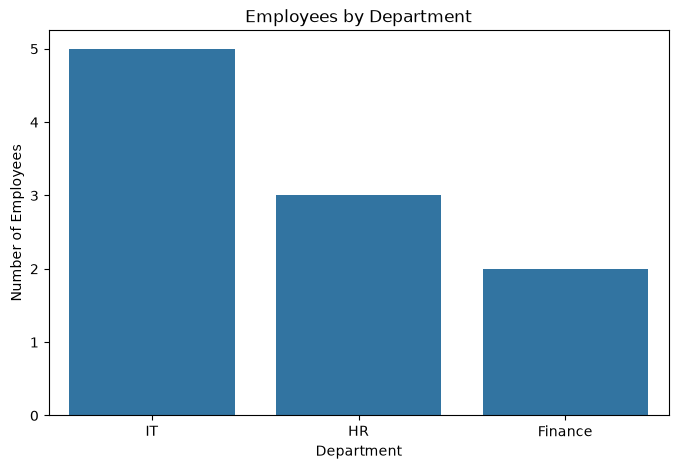

In [10]:
# Step 10: Department Visualization

plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="Department")

plt.title("Employees by Department")
plt.xlabel("Department")
plt.ylabel("Number of Employees")

plt.show()

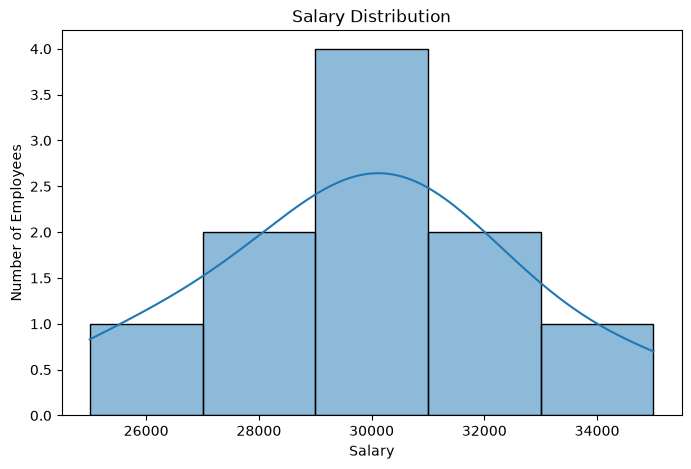

In [11]:
# Step 11: Salary Distribution

plt.figure(figsize=(8, 5))

sns.histplot(data=df, x="Salary", bins=5, kde=True)

plt.title("Salary Distribution")
plt.xlabel("Salary")
plt.ylabel("Number of Employees")

plt.show()

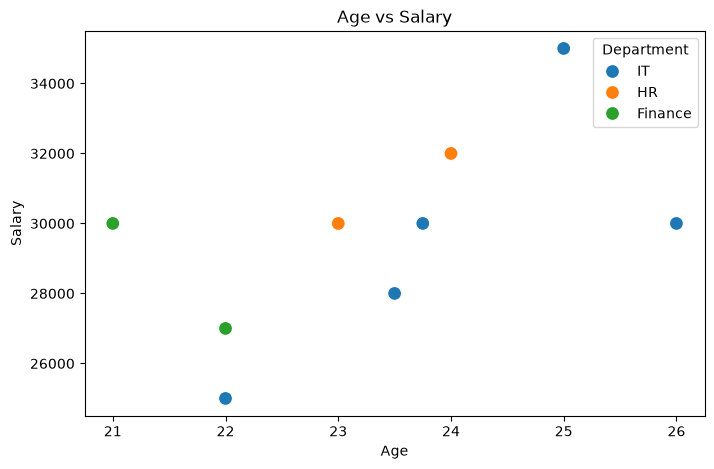

In [12]:
# Step 12: Age vs Salary Visualization

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Age",
    y="Salary",
    hue="Department",
    s=100
)

plt.title("Age vs Salary")
plt.xlabel("Age")
plt.ylabel("Salary")

plt.show()

In [13]:
# Step 13: Summary Statistics

print("Summary Statistics:")
display(df.describe())

print("\nEmployees by Department:")
print(df["Department"].value_counts())

Summary Statistics:


,Age,Salary,Join_Date
count,10.000000,10.000000,10
mean,23.425000,29900.000000,2024-05-02 02:24:00
min,21.000000,25000.000000,2024-01-10 00:00:00
25%,22.250000,28500.000000,2024-02-23 12:00:00
50%,23.625000,30000.000000,2024-04-23 12:00:00
75%,24.000000,31500.000000,2024-07-04 12:00:00
max,26.000000,35000.000000,2024-09-15 00:00:00
std,1.490945,2806.737925,NaN



Employees by Department:
Department
IT         5
HR         3
Finance    2
Name: count, dtype: int64
